# 05 — Reassociate and review 157 events using differential travel-time corrections

This notebook starts from the 157-event legacy catalogue and the preserved
manual picks, but it does **not** assume that each raw pick belongs to the
event whose uncorrected catalogue window happens to contain it.

Instead, it:

1. corrects HD1–HD3 pick times for predicted differential acoustic travel
   time from SLC-40;
2. associates corrected picks into events using a short fixed time window;
3. enforces at most one pick per infrasound channel in each event;
4. compares the reconstructed corrected-time clusters with the 157-event
   catalogue;
5. produces separate unshifted and travel-time-shifted waveform figures;
6. forms aligned infrasound stacks to test whether time shifting improves
   coherence and signal-to-noise ratio.

The 157-event catalogue remains the working legacy reference. The earlier
153-event catalogue is not used in this notebook.

## Interpretation of the time correction

For a pick on channel \(i\),

\[
t_i^{\mathrm{reduced}}
=
t_i
-

rac{r_i-r_\mathrm{ref}}{c_\mathrm{eff}},
\]

where \(r_i\) is the source-to-sensor distance, \(r_\mathrm{ref}\) is the
distance to the reference sensor, and \(c_\mathrm{eff}\) is the wind-corrected
acoustic speed.

The same correction is applied to infrasound waveforms before stacking.
HD2 is used as the reference channel by default because it is the nearest of
the three infrasound sensors to SLC-40.

## 1. Imports and project paths

In [1]:
from pathlib import Path
from collections.abc import Mapping
import html
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from obspy import Stream, Trace, UTCDateTime, read

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from project_config import ensure_output_dirs

PATHS = ensure_output_dirs(PROJECT_ROOT)
DERIVED_DIR = PATHS["derived"]

LEGACY_EXPORT_DIR = PROJECT_ROOT / "metadata" / "legacy_export"

PICK_FILE = LEGACY_EXPORT_DIR / "manual_arrival_picks.csv"
CATALOG_157_FILE = (
    LEGACY_EXPORT_DIR / "legacy_catalog_157_events.csv"
)
STREAM_FILE = DERIVED_DIR / "bchh_corrected_analysis_window.pkl"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "event_waveform_review_reduced_time"
UNSHIFTED_PNG_DIR = OUTPUT_DIR / "unshifted_png"
SHIFTED_PNG_DIR = OUTPUT_DIR / "shifted_png"
CONTACT_SHEET_DIR = OUTPUT_DIR / "contact_sheets"
CLUSTER_DIR = OUTPUT_DIR / "derived"

for directory in [
    OUTPUT_DIR,
    UNSHIFTED_PNG_DIR,
    SHIFTED_PNG_DIR,
    CONTACT_SHEET_DIR,
    CLUSTER_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Corrected stream: {STREAM_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper
Corrected stream: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/derived/bchh_corrected_analysis_window.pkl
Output directory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/event_waveform_review_reduced_time


## 2. Configuration

In [2]:
# Source-to-sensor distances established from the surveyed BCHH geometry.
BCHH_INFRASOUND_DISTANCES_M = {
    "HD1": 1442.2,
    "HD2": 1410.2,
    "HD3": 1414.8,
}

REFERENCE_CHANNEL = "HD2"

# Replace this with the final result from the weather-analysis notebook.
# A value near 359 m/s is consistent with the strongest-event travel times.
WIND_CORRECTED_ACOUSTIC_SPEED_MPS = 351.0

# Candidate association windows to compare after differential correction.
ASSOCIATION_WINDOWS_S = np.array([
    0.008,
    0.012,
    0.016,
    0.020,
    0.024,
    0.030,
    0.040,
    0.050,
    0.060,
])

# Default used for figures and exported reconstructed catalogue.
DEFAULT_ASSOCIATION_WINDOW_S = 0.04 #0.024

# Require at least two distinct infrasound channels.
MINIMUM_CHANNEL_COUNT = 2

# Match reconstructed events to the legacy catalogue by corrected-time
# midpoint, provided the difference is not too large.
MAX_LEGACY_MATCH_DIFFERENCE_S = 0.20

# Unshifted review plots retain enough context to show neighboring arrivals.
UNSHIFTED_PRE_S = 0.12
UNSHIFTED_POST_S = 0.45

# Shifted plots can use a shorter window because inter-sensor delay is removed.
SHIFTED_PRE_S = 0.06
SHIFTED_POST_S = 0.18

SEISMIC_CHANNELS = ("HHZ", "HHN", "HHE")
INFRASOUND_CHANNELS = ("HD1", "HD2", "HD3")

SEISMIC_LABELS = {
    "HHZ": "Vertical",
    "HHN": "North",
    "HHE": "East",
}

PICK_MARKER_SIZE = 52
PICK_MARKER_COLOR = "tab:orange"
PICK_EDGE_COLOR = "black"

WRITE_ALL_UNSHIFTED_PNGS = True
WRITE_ALL_SHIFTED_PNGS = True
WRITE_MULTIPAGE_PDFS = False
WRITE_CONTACT_SHEETS = True
WRITE_HTML_GALLERY = True

## 3. Load waveforms, picks, and the 157-event catalogue

In [3]:
for required_file in [
    STREAM_FILE,
    PICK_FILE,
    CATALOG_157_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required input not found: {required_file}"
        )

st_corr = read(str(STREAM_FILE), format="PICKLE")
picks_all = pd.read_csv(PICK_FILE)
catalog_157 = pd.read_csv(CATALOG_157_FILE)

picks_all["arrival_time"] = pd.to_datetime(
    picks_all["arrivalTimeEpochS"],
    unit="s",
    utc=True,
)
picks_all["channel"] = (
    picks_all["channel"]
    .astype(str)
    .str.upper()
    .str.strip()
)
picks_all["phase_normalized"] = (
    picks_all["phase"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

if "isDeleted" in picks_all.columns:
    picks_all["is_deleted"] = (
        picks_all["isDeleted"]
        .astype(str)
        .str.lower()
        .isin(["true", "1"])
    )
else:
    picks_all["is_deleted"] = (
        picks_all["phase_normalized"] == "del"
    )

catalog_157["on_time"] = pd.to_datetime(
    catalog_157["onTimeEpochS"],
    unit="s",
    utc=True,
)
catalog_157["off_time"] = pd.to_datetime(
    catalog_157["offTimeEpochS"],
    unit="s",
    utc=True,
)

accepted_infrasound = picks_all.loc[
    picks_all["channel"].isin(INFRASOUND_CHANNELS)
    & picks_all["phase_normalized"].eq("n")
    & ~picks_all["is_deleted"]
    & picks_all["arrivalTimeEpochS"].between(
        catalog_157["onTimeEpochS"].min() - 1.0,
        catalog_157["offTimeEpochS"].max() + 1.0,
        inclusive="both",
    )
].copy()

accepted_infrasound = accepted_infrasound.sort_values(
    ["arrivalTimeEpochS", "channel", "pickIndex"]
).reset_index(drop=True)

print(st_corr)
st_corr.filter(type='highpass', freq=10, corners=2)
print(f"Accepted infrasound picks: {len(accepted_infrasound)}")
print(f"Legacy events: {len(catalog_157)}")

6 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
Accepted infrasound picks: 384
Legacy events: 157


## 4. Differential travel-time corrections

In [4]:
def differential_delays_s(
    sensor_distances_m: Mapping[str, float],
    *,
    effective_acoustic_speed_mps: float,
    reference_channel: str,
) -> dict[str, float]:
    if effective_acoustic_speed_mps <= 0:
        raise ValueError(
            "effective_acoustic_speed_mps must be positive"
        )
    if reference_channel not in sensor_distances_m:
        raise KeyError(
            f"Reference channel {reference_channel!r} has no distance"
        )

    reference_distance_m = sensor_distances_m[reference_channel]

    return {
        channel: (
            distance_m - reference_distance_m
        ) / effective_acoustic_speed_mps
        for channel, distance_m in sensor_distances_m.items()
    }


DIFFERENTIAL_DELAYS_S = differential_delays_s(
    BCHH_INFRASOUND_DISTANCES_M,
    effective_acoustic_speed_mps=(
        WIND_CORRECTED_ACOUSTIC_SPEED_MPS
    ),
    reference_channel=REFERENCE_CHANNEL,
)

display(
    pd.DataFrame({
        "channel": list(DIFFERENTIAL_DELAYS_S),
        "distance_m": [
            BCHH_INFRASOUND_DISTANCES_M[channel]
            for channel in DIFFERENTIAL_DELAYS_S
        ],
        "delay_relative_to_reference_s": [
            DIFFERENTIAL_DELAYS_S[channel]
            for channel in DIFFERENTIAL_DELAYS_S
        ],
    })
)

,channel,distance_m,delay_relative_to_reference_s
0,HD1,1442.2,0.091168
1,HD2,1410.2,0.000000
2,HD3,1414.8,0.013105


In [5]:
print(WIND_CORRECTED_ACOUSTIC_SPEED_MPS)

351.0


In [6]:
def add_reduced_pick_times(
    picks: pd.DataFrame,
    delays_s: Mapping[str, float],
) -> pd.DataFrame:
    out = picks.copy()

    missing_channels = (
        set(out["channel"].unique()) - set(delays_s)
    )
    if missing_channels:
        raise KeyError(
            f"Missing delays for channels: {sorted(missing_channels)}"
        )

    out["predicted_relative_delay_s"] = (
        out["channel"].map(delays_s)
    )
    out["reduced_pick_epoch_s"] = (
        out["arrivalTimeEpochS"]
        - out["predicted_relative_delay_s"]
    )
    out["reduced_pick_time"] = pd.to_datetime(
        out["reduced_pick_epoch_s"],
        unit="s",
        utc=True,
    )
    return out


accepted_reduced = add_reduced_pick_times(
    accepted_infrasound,
    DIFFERENTIAL_DELAYS_S,
)

display(
    accepted_reduced[
        [
            "pickIndex",
            "channel",
            "arrival_time",
            "predicted_relative_delay_s",
            "reduced_pick_time",
        ]
    ].head(20)
)

,pickIndex,channel,arrival_time,predicted_relative_delay_s,reduced_pick_time
0,193,HD2,2016-09-01 13:07:15.927999973+00:00,0.000000,2016-09-01 13:07:15.927999973+00:00
1,194,HD3,2016-09-01 13:07:15.940000057+00:00,0.013105,2016-09-01 13:07:15.926894665+00:00
2,198,HD1,2016-09-01 13:07:16.016000032+00:00,0.091168,2016-09-01 13:07:15.924831867+00:00
3,199,HD2,2016-09-01 13:07:16.066999911+00:00,0.000000,2016-09-01 13:07:16.066999911+00:00
4,200,HD3,2016-09-01 13:07:16.069999933+00:00,0.013105,2016-09-01 13:07:16.056894541+00:00
5,201,HD1,2016-09-01 13:07:16.145999908+00:00,0.091168,2016-09-01 13:07:16.054831743+00:00
6,202,HD2,2016-09-01 13:07:16.255000114+00:00,0.000000,2016-09-01 13:07:16.255000114+00:00
7,203,HD3,2016-09-01 13:07:16.265000105+00:00,0.013105,2016-09-01 13:07:16.251894712+00:00
8,204,HD1,2016-09-01 13:07:16.345999956+00:00,0.091168,2016-09-01 13:07:16.254831790+00:00
9,205,HD3,2016-09-01 13:07:16.444999933+00:00,0.013105,2016-09-01 13:07:16.431894541+00:00


## 5. Reassociate corrected picks into events

The algorithm uses the earliest unassigned corrected pick as a seed. It then
considers all corrected picks inside a fixed forward window and retains the
closest pick from each channel. A cluster is accepted only when at least two
distinct infrasound channels are represented.

A seed that cannot form a valid multi-channel event is marked unassociated;
it is not allowed to chain arbitrarily into a later cluster.

In [7]:
def associate_reduced_time_picks(
    picks: pd.DataFrame,
    *,
    association_window_s: float,
    minimum_channel_count: int = 2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = picks.sort_values(
        ["reduced_pick_epoch_s", "channel", "pickIndex"]
    ).copy()

    work["reconstructed_event_number"] = 0
    work["association_status"] = "unassigned"
    work["association_residual_s"] = np.nan

    event_rows = []
    next_event_number = 1

    remaining = set(work.index)

    while remaining:
        seed_index = min(
            remaining,
            key=lambda idx: (
                work.at[idx, "reduced_pick_epoch_s"],
                work.at[idx, "pickIndex"],
            ),
        )
        seed_time = float(
            work.at[seed_index, "reduced_pick_epoch_s"]
        )

        candidate_indices = [
            idx
            for idx in remaining
            if (
                0.0
                <= work.at[idx, "reduced_pick_epoch_s"] - seed_time
                <= association_window_s
            )
        ]

        candidates = work.loc[candidate_indices].copy()
        candidates["distance_from_seed_s"] = (
            candidates["reduced_pick_epoch_s"] - seed_time
        ).abs()

        selected = (
            candidates
            .sort_values(
                [
                    "channel",
                    "distance_from_seed_s",
                    "pickIndex",
                ]
            )
            .drop_duplicates("channel", keep="first")
        )

        if selected["channel"].nunique() >= minimum_channel_count:
            center_time = float(
                selected["reduced_pick_epoch_s"].median()
            )
            selected_indices = list(selected.index)

            work.loc[
                selected_indices,
                "reconstructed_event_number",
            ] = next_event_number
            work.loc[
                selected_indices,
                "association_status",
            ] = "associated"
            work.loc[
                selected_indices,
                "association_residual_s",
            ] = (
                work.loc[
                    selected_indices,
                    "reduced_pick_epoch_s",
                ]
                - center_time
            )

            event_rows.append({
                "reconstructed_event_number": next_event_number,
                "reduced_event_epoch_s": center_time,
                "first_reduced_pick_epoch_s": float(
                    selected["reduced_pick_epoch_s"].min()
                ),
                "last_reduced_pick_epoch_s": float(
                    selected["reduced_pick_epoch_s"].max()
                ),
                "corrected_pick_span_s": float(
                    selected["reduced_pick_epoch_s"].max()
                    - selected["reduced_pick_epoch_s"].min()
                ),
                "pick_count": len(selected),
                "channel_count": int(
                    selected["channel"].nunique()
                ),
                "channels": ",".join(
                    sorted(selected["channel"].unique())
                ),
                "pick_indices": ",".join(
                    selected["pickIndex"]
                    .astype(int)
                    .astype(str)
                ),
                "observed_first_pick_epoch_s": float(
                    selected["arrivalTimeEpochS"].min()
                ),
                "observed_last_pick_epoch_s": float(
                    selected["arrivalTimeEpochS"].max()
                ),
            })

            for idx in selected_indices:
                remaining.remove(idx)

            # Any unused candidate from a duplicated channel remains
            # available for a later physical event.
            next_event_number += 1

        else:
            work.at[
                seed_index,
                "association_status",
            ] = "unassociated_seed"
            remaining.remove(seed_index)

    events = pd.DataFrame(event_rows)

    if not events.empty:
        events["reduced_event_time"] = pd.to_datetime(
            events["reduced_event_epoch_s"],
            unit="s",
            utc=True,
        )
        events["observed_first_pick_time"] = pd.to_datetime(
            events["observed_first_pick_epoch_s"],
            unit="s",
            utc=True,
        )
        events["observed_last_pick_time"] = pd.to_datetime(
            events["observed_last_pick_epoch_s"],
            unit="s",
            utc=True,
        )

    return work, events

## 6. Sweep corrected-time association windows

In [8]:
window_summary_rows = []
association_results = {}

for window_s in ASSOCIATION_WINDOWS_S:
    assigned, events = associate_reduced_time_picks(
        accepted_reduced,
        association_window_s=float(window_s),
        minimum_channel_count=MINIMUM_CHANNEL_COUNT,
    )
    association_results[float(window_s)] = (
        assigned,
        events,
    )

    window_summary_rows.append({
        "association_window_s": float(window_s),
        "reconstructed_event_count": len(events),
        "associated_pick_count": int(
            (assigned["association_status"] == "associated").sum()
        ),
        "unassociated_pick_count": int(
            (assigned["association_status"] != "associated").sum()
        ),
        "three_channel_event_count": int(
            (events["channel_count"] == 3).sum()
        ) if len(events) else 0,
        "two_channel_event_count": int(
            (events["channel_count"] == 2).sum()
        ) if len(events) else 0,
        "median_corrected_pick_span_s": (
            events["corrected_pick_span_s"].median()
            if len(events)
            else np.nan
        ),
        "p95_corrected_pick_span_s": (
            events["corrected_pick_span_s"].quantile(0.95)
            if len(events)
            else np.nan
        ),
    })

window_summary = pd.DataFrame(window_summary_rows)
display(window_summary)

window_summary.to_csv(
    CLUSTER_DIR / "reduced_time_association_window_sweep.csv",
    index=False,
)

,association_window_s,reconstructed_event_count,associated_pick_count,unassociated_pick_count,three_channel_event_count,two_channel_event_count,median_corrected_pick_span_s,p95_corrected_pick_span_s
0,0.008,123,291,93,45,78,0.003168,0.007168
1,0.012,141,339,45,57,84,0.005105,0.010105
2,0.016,148,355,29,59,89,0.005105,0.012105
3,0.020,151,363,21,61,90,0.005105,0.013000
4,0.024,152,366,18,62,90,0.005105,0.014555
5,0.030,152,366,18,62,90,0.005105,0.014555
6,0.040,154,371,13,63,91,0.005105,0.016928
7,0.050,154,371,13,63,91,0.005105,0.016928
8,0.060,154,371,13,63,91,0.005105,0.016928


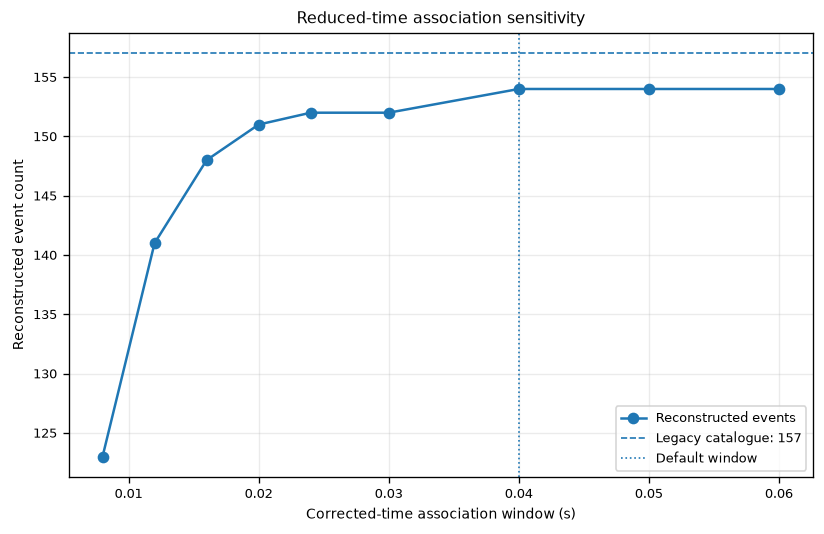

In [9]:
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.plot(
    window_summary["association_window_s"],
    window_summary["reconstructed_event_count"],
    marker="o",
    label="Reconstructed events",
)
ax.axhline(
    157,
    linestyle="--",
    linewidth=1.0,
    label="Legacy catalogue: 157",
)
ax.axvline(
    DEFAULT_ASSOCIATION_WINDOW_S,
    linestyle=":",
    linewidth=1.0,
    label="Default window",
)
ax.set_xlabel("Corrected-time association window (s)")
ax.set_ylabel("Reconstructed event count")
ax.set_title("Reduced-time association sensitivity")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    OUTPUT_DIR / "reduced_time_event_count_vs_window.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 7. Adopt the default corrected-time catalogue

In [10]:
assigned_picks, reconstructed_events = association_results[
    float(DEFAULT_ASSOCIATION_WINDOW_S)
]

assigned_picks.to_csv(
    CLUSTER_DIR / "reduced_time_pick_assignments.csv",
    index=False,
)
reconstructed_events.to_csv(
    CLUSTER_DIR / "reconstructed_reduced_time_events.csv",
    index=False,
)

print(
    f"Reconstructed events: {len(reconstructed_events)}"
)
print(
    "Three-channel events:",
    int((reconstructed_events["channel_count"] == 3).sum()),
)
print(
    "Two-channel events:",
    int((reconstructed_events["channel_count"] == 2).sum()),
)
print(
    "Unassociated picks:",
    int(
        (assigned_picks["association_status"] != "associated").sum()
    ),
)

display(reconstructed_events.head(15))

Reconstructed events: 154
Three-channel events: 63
Two-channel events: 91
Unassociated picks: 13


,reconstructed_event_number,reduced_event_epoch_s,first_reduced_pick_epoch_s,last_reduced_pick_epoch_s,corrected_pick_span_s,pick_count,channel_count,channels,pick_indices,observed_first_pick_epoch_s,observed_last_pick_epoch_s,reduced_event_time,observed_first_pick_time,observed_last_pick_time
0,1,1.472735e+09,1.472735e+09,1.472735e+09,0.003168,3,3,"HD1,HD2,HD3","198,193,194",1.472735e+09,1.472735e+09,2016-09-01 13:07:15.926894665+00:00,2016-09-01 13:07:15.927999973+00:00,2016-09-01 13:07:16.016000032+00:00
1,2,1.472735e+09,1.472735e+09,1.472735e+09,0.012168,3,3,"HD1,HD2,HD3","201,199,200",1.472735e+09,1.472735e+09,2016-09-01 13:07:16.056894541+00:00,2016-09-01 13:07:16.066999911+00:00,2016-09-01 13:07:16.145999908+00:00
2,3,1.472735e+09,1.472735e+09,1.472735e+09,0.003105,3,3,"HD1,HD2,HD3","204,202,203",1.472735e+09,1.472735e+09,2016-09-01 13:07:16.254831790+00:00,2016-09-01 13:07:16.255000114+00:00,2016-09-01 13:07:16.345999956+00:00
3,4,1.472735e+09,1.472735e+09,1.472735e+09,0.030105,2,2,"HD2,HD3","206,205",1.472735e+09,1.472735e+09,2016-09-01 13:07:16.446947098+00:00,2016-09-01 13:07:16.444999933+00:00,2016-09-01 13:07:16.461999893+00:00
4,5,1.472735e+09,1.472735e+09,1.472735e+09,0.001105,2,2,"HD2,HD3","207,208",1.472735e+09,1.472735e+09,2016-09-01 13:07:16.799447298+00:00,2016-09-01 13:07:16.799999952+00:00,2016-09-01 13:07:16.812000036+00:00
5,6,1.472735e+09,1.472735e+09,1.472735e+09,0.002937,3,3,"HD1,HD2,HD3","211,209,210",1.472735e+09,1.472735e+09,2016-09-01 13:07:17.242000103+00:00,2016-09-01 13:07:17.242000103+00:00,2016-09-01 13:07:17.335000038+00:00
6,7,1.472735e+09,1.472735e+09,1.472735e+09,0.004063,3,3,"HD1,HD2,HD3","215,213,214",1.472735e+09,1.472735e+09,2016-09-01 13:07:17.634000063+00:00,2016-09-01 13:07:17.634000063+00:00,2016-09-01 13:07:17.723000050+00:00
7,8,1.472735e+09,1.472735e+09,1.472735e+09,0.005168,3,3,"HD1,HD2,HD3","218,216,217",1.472735e+09,1.472735e+09,2016-09-01 13:07:17.894894600+00:00,2016-09-01 13:07:17.895999908+00:00,2016-09-01 13:07:17.982000113+00:00
8,9,1.472735e+09,1.472735e+09,1.472735e+09,0.003168,3,3,"HD1,HD2,HD3","221,219,220",1.472735e+09,1.472735e+09,2016-09-01 13:07:18.110894680+00:00,2016-09-01 13:07:18.111999989+00:00,2016-09-01 13:07:18.200000048+00:00
9,10,1.472735e+09,1.472735e+09,1.472735e+09,0.001895,2,2,"HD2,HD3","223,224",1.472735e+09,1.472735e+09,2016-09-01 13:07:18.388947487+00:00,2016-09-01 13:07:18.388000011+00:00,2016-09-01 13:07:18.403000116+00:00


## 8. Match reconstructed corrected-time events to the 157-event catalogue

A reconstructed event is matched to the nearest legacy event midpoint.
Matches exceeding `MAX_LEGACY_MATCH_DIFFERENCE_S` are retained as unmatched.
This comparison is diagnostic only; it does not alter the reconstructed
clustering.

In [11]:
catalog_157 = catalog_157.copy()
catalog_157["legacy_midpoint_epoch_s"] = (
    catalog_157["onTimeEpochS"]
    + catalog_157["offTimeEpochS"]
) / 2.0

legacy_midpoints = catalog_157[
    "legacy_midpoint_epoch_s"
].to_numpy(dtype=float)

match_rows = []

for event in reconstructed_events.itertuples(index=False):
    differences = (
        legacy_midpoints - event.reduced_event_epoch_s
    )
    best_index = int(np.argmin(np.abs(differences)))
    difference_s = float(differences[best_index])
    legacy_row = catalog_157.iloc[best_index]

    matched = (
        abs(difference_s)
        <= MAX_LEGACY_MATCH_DIFFERENCE_S
    )

    match_rows.append({
        "reconstructed_event_number": (
            event.reconstructed_event_number
        ),
        "legacy_event_number": (
            int(legacy_row["catalogEventNumber"])
            if matched
            else np.nan
        ),
        "legacy_match_difference_s": difference_s,
        "legacy_match_status": (
            "matched" if matched else "unmatched"
        ),
    })

reconstructed_matches = pd.DataFrame(match_rows)

reconstructed_events = reconstructed_events.merge(
    reconstructed_matches,
    on="reconstructed_event_number",
    how="left",
)

reconstructed_events.to_csv(
    CLUSTER_DIR
    / "reconstructed_reduced_time_events_with_legacy_matches.csv",
    index=False,
)

display(
    reconstructed_events[
        "legacy_match_status"
    ].value_counts()
)

legacy_match_status
matched      151
unmatched      3
Name: count, dtype: int64

## 9. Shift infrasound traces to the reference sensor

The waveform time correction uses the same differential delays as the pick
correction. A positive HD1 delay means its waveform is shifted earlier by
that amount so that an SLC-40 arrival aligns with HD2.

In [12]:
def select_one_trace(stream: Stream, channel: str) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(
    trace: Trace,
    delay_s: float,
) -> Trace:
    shifted = trace.copy()
    # Moving the start time earlier by delay_s makes samples appear earlier
    # on an absolute time axis without interpolation or resampling.
    shifted.stats.starttime -= delay_s
    return shifted


def shifted_infrasound_stream(
    stream: Stream,
    delays_s: Mapping[str, float],
) -> Stream:
    shifted = Stream()

    for channel in INFRASOUND_CHANNELS:
        trace = select_one_trace(stream, channel)
        shifted += shift_trace_to_reference(
            trace,
            float(delays_s[channel]),
        )

    return shifted

## 10. Stack aligned infrasound waveforms

Each shifted trace is sampled on a common reference-time grid. The stack is
the sample-by-sample mean of the three aligned pressure traces. A median
stack is also calculated because it is less sensitive to one anomalous
channel.

In [13]:
def sample_trace_on_common_grid(
    trace: Trace,
    epoch_grid_s: np.ndarray,
) -> np.ndarray:
    trace_times_s = (
        float(trace.stats.starttime.timestamp)
        + np.arange(trace.stats.npts)
        / float(trace.stats.sampling_rate)
    )

    return np.interp(
        epoch_grid_s,
        trace_times_s,
        trace.data.astype(float),
        left=np.nan,
        right=np.nan,
    )


def build_shifted_pressure_matrix(
    shifted_stream: Stream,
    *,
    start_epoch_s: float,
    end_epoch_s: float,
    sampling_rate_hz: float,
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    sample_count = int(
        round((end_epoch_s - start_epoch_s) * sampling_rate_hz)
    ) + 1

    epoch_grid_s = (
        start_epoch_s
        + np.arange(sample_count) / sampling_rate_hz
    )

    arrays = {
        channel: sample_trace_on_common_grid(
            select_one_trace(shifted_stream, channel),
            epoch_grid_s,
        )
        for channel in INFRASOUND_CHANNELS
    }

    matrix = np.vstack([
        arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])

    return epoch_grid_s, arrays


def stack_signal_to_noise_ratio(
    data: np.ndarray,
    time_s: np.ndarray,
    *,
    noise_window: tuple[float, float],
    signal_window: tuple[float, float],
) -> float:
    noise_mask = (
        (time_s >= noise_window[0])
        & (time_s <= noise_window[1])
    )
    signal_mask = (
        (time_s >= signal_window[0])
        & (time_s <= signal_window[1])
    )

    noise_rms = np.sqrt(
        np.nanmean(data[noise_mask] ** 2)
    )
    signal_peak = np.nanmax(
        np.abs(data[signal_mask])
    )

    return (
        signal_peak / noise_rms
        if noise_rms > 0
        else np.nan
    )

## 11. Plotting helpers

Two complementary figures are generated for every reconstructed event:

### Unshifted figure

- original absolute waveform timing;
- manual picks at their observed times;
- the matched legacy 157-event window;
- enough context to see neighboring events.

### Shifted figure

- HD1–HD3 shifted to the HD2 reference time;
- corrected picks shown at reduced times;
- short window centered on the reconstructed event;
- mean and median pressure stacks;
- stack SNR diagnostics.

In [14]:
def value_at_epoch_time(
    trace: Trace,
    epoch_s: float,
) -> tuple[float, float]:
    trace_start_s = float(trace.stats.starttime.timestamp)
    sample_index = int(
        round(
            (epoch_s - trace_start_s)
            * float(trace.stats.sampling_rate)
        )
    )
    sample_index = int(
        np.clip(sample_index, 0, trace.stats.npts - 1)
    )
    sample_epoch_s = (
        trace_start_s
        + sample_index / float(trace.stats.sampling_rate)
    )
    return sample_epoch_s, float(trace.data[sample_index])


def event_assigned_picks(
    event_number: int,
) -> pd.DataFrame:
    return assigned_picks.loc[
        assigned_picks["reconstructed_event_number"]
        == event_number
    ].copy()


def build_unshifted_figure(
    event: pd.Series,
    stream: Stream,
):
    event_number = int(
        event["reconstructed_event_number"]
    )
    center_epoch_s = float(
        event["reduced_event_epoch_s"]
    )

    event_picks = event_assigned_picks(event_number)
    observed_start_s = float(
        event_picks["arrivalTimeEpochS"].min()
    )
    observed_end_s = float(
        event_picks["arrivalTimeEpochS"].max()
    )

    plot_start_s = min(
        center_epoch_s - UNSHIFTED_PRE_S,
        observed_start_s - 0.04,
    )
    plot_end_s = max(
        center_epoch_s + UNSHIFTED_POST_S,
        observed_end_s + 0.20,
    )

    event_stream = stream.copy().trim(
        UTCDateTime(plot_start_s),
        UTCDateTime(plot_end_s),
        pad=False,
    )

    reference_time = UTCDateTime(center_epoch_s)

    seismic = [
        select_one_trace(event_stream, channel)
        for channel in SEISMIC_CHANNELS
    ]
    pressure = [
        select_one_trace(event_stream, channel)
        for channel in INFRASOUND_CHANNELS
    ]

    fig = plt.figure(
        figsize=(12.0, 7.1),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        3,
        2,
        width_ratios=(1.0, 1.25),
        wspace=0.08,
        hspace=0.05,
    )
    seismic_axes = [
        fig.add_subplot(grid[i, 0])
        for i in range(3)
    ]
    pressure_axes = [
        fig.add_subplot(grid[i, 1])
        for i in range(3)
    ]

    seismic_limit = max(
        np.nanmax(np.abs(trace.data.astype(float)))
        for trace in seismic
    )
    seismic_limit = max(seismic_limit * 1.08, 1e-12)

    pressure_limit = max(
        np.nanmax(np.abs(trace.data.astype(float)))
        for trace in pressure
    )
    pressure_limit = max(pressure_limit * 1.08, 1.0)

    axes_by_channel = {}

    for index, (axis, trace) in enumerate(
        zip(seismic_axes, seismic)
    ):
        axis.plot(
            trace.times(reftime=reference_time),
            trace.data.astype(float),
            linewidth=0.9,
        )
        axis.axhline(0.0, linewidth=0.5, alpha=0.5)
        axis.set_ylim(-seismic_limit, seismic_limit)
        axis.text(
            0.02,
            0.86,
            SEISMIC_LABELS[trace.stats.channel],
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        if index < 2:
            axis.tick_params(labelbottom=False)
        axis.spines[["top", "right"]].set_visible(False)
        axes_by_channel[trace.stats.channel] = (
            axis,
            trace,
        )

    for index, (axis, trace) in enumerate(
        zip(pressure_axes, pressure)
    ):
        axis.plot(
            trace.times(reftime=reference_time),
            trace.data.astype(float),
            linewidth=1.0,
        )
        axis.axhline(0.0, linewidth=0.5, alpha=0.5)
        axis.set_ylim(-pressure_limit, pressure_limit)
        axis.text(
            0.02,
            0.86,
            trace.stats.channel,
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        if index < 2:
            axis.tick_params(labelbottom=False)
        axis.spines[["top", "right"]].set_visible(False)
        axes_by_channel[trace.stats.channel] = (
            axis,
            trace,
        )

    all_axes = seismic_axes + pressure_axes

    for axis in all_axes:
        axis.axvline(
            0.0,
            linestyle="-",
            linewidth=1.1,
            alpha=0.9,
        )

    legacy_event_number = event["legacy_event_number"]

    if np.isfinite(legacy_event_number):
        legacy_row = catalog_157.loc[
            catalog_157["catalogEventNumber"]
            == int(legacy_event_number)
        ].iloc[0]

        legacy_start_rel_s = (
            float(legacy_row["onTimeEpochS"])
            - center_epoch_s
        )
        legacy_end_rel_s = (
            float(legacy_row["offTimeEpochS"])
            - center_epoch_s
        )

        for axis in pressure_axes:
            axis.axvspan(
                legacy_start_rel_s,
                legacy_end_rel_s,
                alpha=0.12,
            )

        for axis in all_axes:
            axis.axvline(
                legacy_start_rel_s,
                linestyle="--",
                linewidth=0.9,
            )
            axis.axvline(
                legacy_end_rel_s,
                linestyle="--",
                linewidth=0.9,
            )

    for pick in event_picks.itertuples(index=False):
        axis, trace = axes_by_channel[pick.channel]
        sample_epoch_s, sample_value = value_at_epoch_time(
            trace,
            float(pick.arrivalTimeEpochS),
        )
        relative_s = sample_epoch_s - center_epoch_s

        axis.scatter(
            [relative_s],
            [sample_value],
            s=PICK_MARKER_SIZE,
            facecolors=PICK_MARKER_COLOR,
            edgecolors=PICK_EDGE_COLOR,
            linewidths=0.7,
            zorder=7,
        )
        axis.annotate(
            str(int(pick.pickIndex)),
            (relative_s, sample_value),
            xytext=(4, 6),
            textcoords="offset points",
            fontsize=6.5,
            arrowprops={
                "arrowstyle": "-",
                "linewidth": 0.45,
                "shrinkA": 0,
                "shrinkB": 3,
            },
        )

    x_min = plot_start_s - center_epoch_s
    x_max = plot_end_s - center_epoch_s

    for axis in all_axes:
        axis.set_xlim(x_min, x_max)
        axis.grid(axis="x", linewidth=0.4, alpha=0.3)

    seismic_axes[0].set_title(
        "Ground velocity",
        fontweight="bold",
    )
    pressure_axes[0].set_title(
        "Observed acoustic pressure",
        fontweight="bold",
    )
    seismic_axes[1].set_ylabel(
        "Ground velocity (m s$^{-1}$)"
    )
    pressure_axes[1].set_ylabel("Pressure (Pa)")

    time_label = UTCDateTime(
        center_epoch_s
    ).strftime("%H:%M:%S.%f")[:-3]

    seismic_axes[-1].set_xlabel(
        f"Time relative to reduced event time {time_label} UTC (s)"
    )
    pressure_axes[-1].set_xlabel(
        f"Time relative to reduced event time {time_label} UTC (s)"
    )

    legacy_text = (
        f"{int(legacy_event_number)}"
        if np.isfinite(legacy_event_number)
        else "none"
    )

    fig.suptitle(
        f"Reduced-time event {event_number:03d}; "
        f"channels {event['channels']}; "
        f"corrected span {event['corrected_pick_span_s']:.3f} s\n"
        f"Matched legacy 157-event: {legacy_text}; "
        f"observed picks remain unshifted",
        fontweight="bold",
    )

    return fig


def build_shifted_figure(
    event: pd.Series,
    stream: Stream,
):
    event_number = int(
        event["reconstructed_event_number"]
    )
    center_epoch_s = float(
        event["reduced_event_epoch_s"]
    )

    event_picks = event_assigned_picks(event_number)

    raw_subset = Stream([
        select_one_trace(stream, channel).copy()
        for channel in INFRASOUND_CHANNELS
    ])
    shifted_stream = shifted_infrasound_stream(
        raw_subset,
        DIFFERENTIAL_DELAYS_S,
    )

    plot_start_s = center_epoch_s - SHIFTED_PRE_S
    plot_end_s = center_epoch_s + SHIFTED_POST_S

    trimmed_shifted = shifted_stream.copy().trim(
        UTCDateTime(plot_start_s),
        UTCDateTime(plot_end_s),
        pad=False,
    )

    sampling_rate_hz = float(
        trimmed_shifted[0].stats.sampling_rate
    )
    epoch_grid_s, arrays = build_shifted_pressure_matrix(
        trimmed_shifted,
        start_epoch_s=plot_start_s,
        end_epoch_s=plot_end_s,
        sampling_rate_hz=sampling_rate_hz,
    )

    relative_time_s = epoch_grid_s - center_epoch_s
    matrix = np.vstack([
        arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])

    mean_stack = np.nanmean(matrix, axis=0)
    median_stack = np.nanmedian(matrix, axis=0)

    mean_stack_snr = stack_signal_to_noise_ratio(
        mean_stack,
        relative_time_s,
        noise_window=(-SHIFTED_PRE_S, -0.015),
        signal_window=(-0.015, 0.080),
    )
    median_stack_snr = stack_signal_to_noise_ratio(
        median_stack,
        relative_time_s,
        noise_window=(-SHIFTED_PRE_S, -0.015),
        signal_window=(-0.015, 0.080),
    )

    fig, axes = plt.subplots(
        5,
        1,
        figsize=(9.8, 8.0),
        sharex=True,
        constrained_layout=True,
    )

    pressure_limit = max(
        np.nanmax(np.abs(matrix)),
        np.nanmax(np.abs(mean_stack)),
        np.nanmax(np.abs(median_stack)),
    )
    pressure_limit = max(pressure_limit * 1.08, 1.0)

    axes_by_channel = {}

    for axis, channel in zip(
        axes[:3],
        INFRASOUND_CHANNELS,
    ):
        axis.plot(
            relative_time_s,
            arrays[channel],
            linewidth=1.0,
        )
        axis.axhline(0.0, linewidth=0.5, alpha=0.5)
        axis.axvline(0.0, linewidth=1.0)
        axis.set_ylim(-pressure_limit, pressure_limit)
        axis.text(
            0.015,
            0.82,
            f"{channel} shifted by "
            f"{DIFFERENTIAL_DELAYS_S[channel]:+.3f} s",
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        axis.spines[["top", "right"]].set_visible(False)
        axes_by_channel[channel] = axis

    axes[3].plot(
        relative_time_s,
        mean_stack,
        linewidth=1.2,
    )
    axes[3].axhline(0.0, linewidth=0.5, alpha=0.5)
    axes[3].axvline(0.0, linewidth=1.0)
    axes[3].set_ylim(-pressure_limit, pressure_limit)
    axes[3].text(
        0.015,
        0.82,
        f"Mean stack; SNR {mean_stack_snr:.1f}",
        transform=axes[3].transAxes,
        fontweight="bold",
        va="top",
    )
    axes[3].spines[["top", "right"]].set_visible(False)

    axes[4].plot(
        relative_time_s,
        median_stack,
        linewidth=1.2,
    )
    axes[4].axhline(0.0, linewidth=0.5, alpha=0.5)
    axes[4].axvline(0.0, linewidth=1.0)
    axes[4].set_ylim(-pressure_limit, pressure_limit)
    axes[4].text(
        0.015,
        0.82,
        f"Median stack; SNR {median_stack_snr:.1f}",
        transform=axes[4].transAxes,
        fontweight="bold",
        va="top",
    )
    axes[4].spines[["top", "right"]].set_visible(False)

    for pick in event_picks.itertuples(index=False):
        if pick.channel not in axes_by_channel:
            continue

        axis = axes_by_channel[pick.channel]
        shifted_trace = select_one_trace(
            trimmed_shifted,
            pick.channel,
        )
        sample_epoch_s, sample_value = value_at_epoch_time(
            shifted_trace,
            float(pick.reduced_pick_epoch_s),
        )
        relative_s = sample_epoch_s - center_epoch_s

        axis.scatter(
            [relative_s],
            [sample_value],
            s=PICK_MARKER_SIZE,
            facecolors=PICK_MARKER_COLOR,
            edgecolors=PICK_EDGE_COLOR,
            linewidths=0.7,
            zorder=7,
        )
        axis.annotate(
            str(int(pick.pickIndex)),
            (relative_s, sample_value),
            xytext=(4, 6),
            textcoords="offset points",
            fontsize=6.5,
            arrowprops={
                "arrowstyle": "-",
                "linewidth": 0.45,
                "shrinkA": 0,
                "shrinkB": 3,
            },
        )

    for axis in axes:
        axis.set_xlim(-SHIFTED_PRE_S, SHIFTED_POST_S)
        axis.grid(axis="x", linewidth=0.4, alpha=0.3)

    axes[2].set_ylabel("Pressure (Pa)")
    axes[-1].set_xlabel(
        "Differential-travel-time-corrected time "
        "relative to reconstructed event (s)"
    )

    fig.suptitle(
        f"Reduced-time event {event_number:03d}: shifted infrasound "
        f"and stacks\n"
        f"channels {event['channels']}; corrected pick span "
        f"{event['corrected_pick_span_s']:.3f} s",
        fontweight="bold",
    )

    metadata = {
        "reconstructed_event_number": event_number,
        "mean_stack_snr": mean_stack_snr,
        "median_stack_snr": median_stack_snr,
        "peak_mean_stack_pa": float(
            np.nanmax(np.abs(mean_stack))
        ),
        "peak_median_stack_pa": float(
            np.nanmax(np.abs(median_stack))
        ),
    }

    return fig, metadata

## 12. Preview one reconstructed event

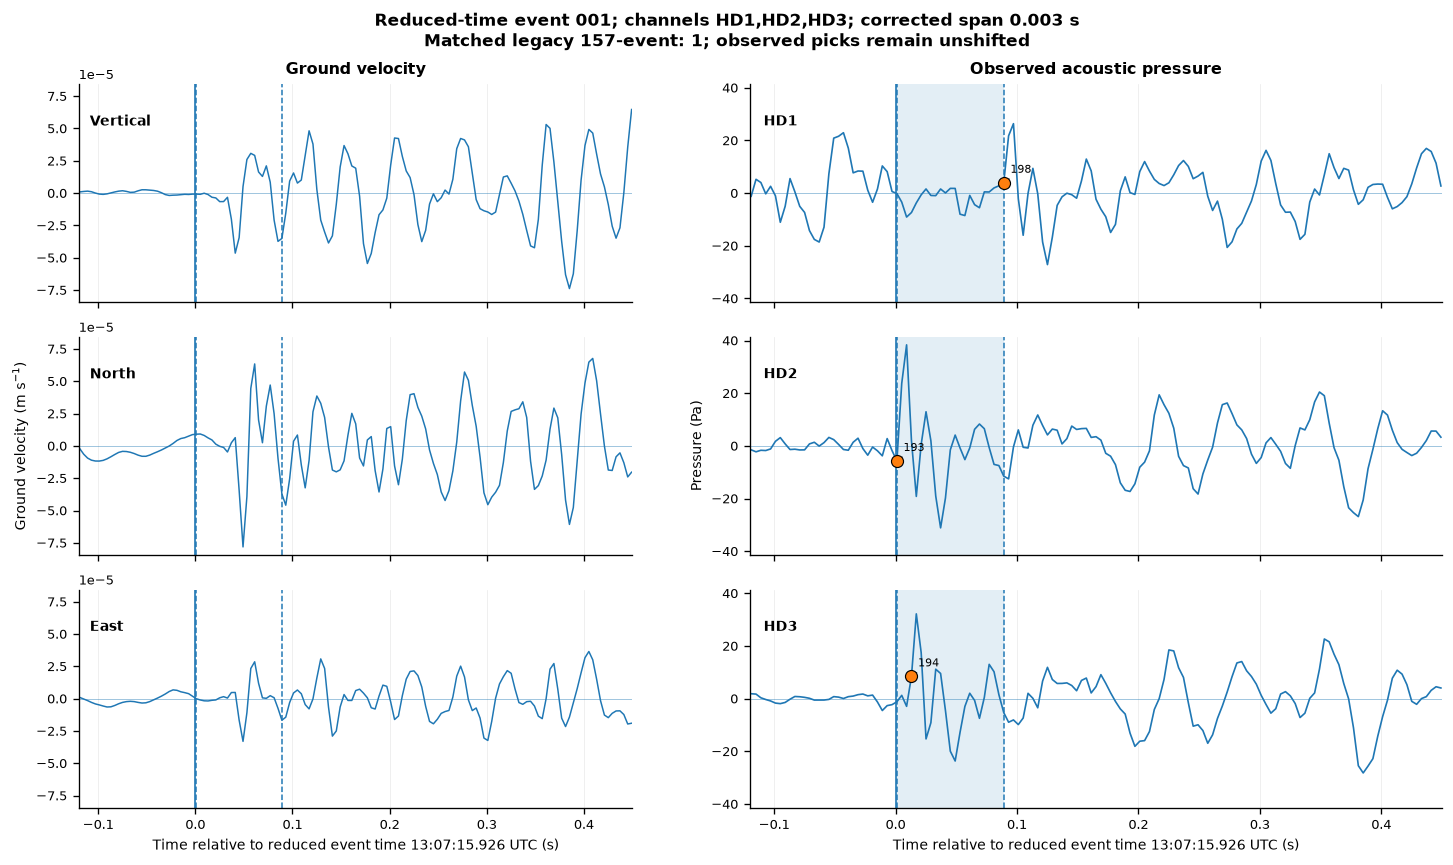

{'reconstructed_event_number': 1, 'mean_stack_snr': np.float64(14.221739344044556), 'median_stack_snr': np.float64(13.379752043366082), 'peak_mean_stack_pa': 24.417235583255557, 'peak_median_stack_pa': 24.138475115105088}


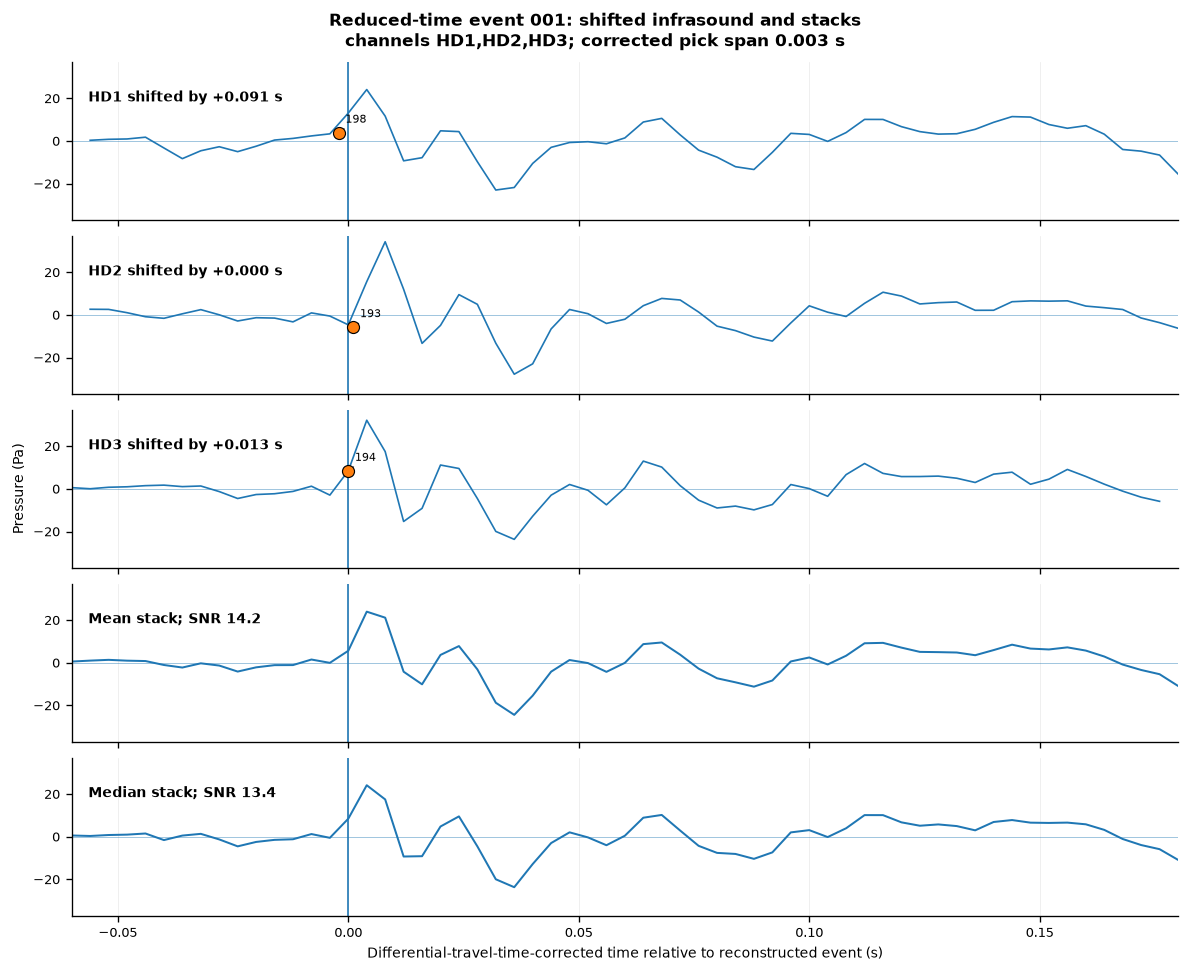

In [15]:
PREVIEW_RECONSTRUCTED_EVENT = 1

preview_event = reconstructed_events.loc[
    reconstructed_events["reconstructed_event_number"]
    == PREVIEW_RECONSTRUCTED_EVENT
].iloc[0]

fig_unshifted = build_unshifted_figure(
    preview_event,
    st_corr,
)
plt.show()

fig_shifted, shifted_metadata = build_shifted_figure(
    preview_event,
    st_corr,
)
print(shifted_metadata)
plt.show()

## 13. Generate all unshifted and shifted event figures

Two independent output directories are used:

```text
outputs/event_waveform_review_reduced_time/unshifted_png/
outputs/event_waveform_review_reduced_time/shifted_png/
```

In [16]:
figure_index_rows = []
stack_metric_rows = []

for row_number, event in reconstructed_events.iterrows():
    event_number = int(
        event["reconstructed_event_number"]
    )
    timestamp_text = pd.to_datetime(
        event["reduced_event_epoch_s"],
        unit="s",
        utc=True,
    ).strftime("%H%M%S%f")[:9]

    unshifted_name = (
        f"event_{event_number:03d}_{timestamp_text}_unshifted.png"
    )
    shifted_name = (
        f"event_{event_number:03d}_{timestamp_text}_shifted.png"
    )

    unshifted_path = UNSHIFTED_PNG_DIR / unshifted_name
    shifted_path = SHIFTED_PNG_DIR / shifted_name

    if WRITE_ALL_UNSHIFTED_PNGS:
        figure = build_unshifted_figure(event, st_corr)
        figure.savefig(
            unshifted_path,
            dpi=220,
            bbox_inches="tight",
        )
        plt.close(figure)

    shifted_figure, stack_metadata = build_shifted_figure(
        event,
        st_corr,
    )

    if WRITE_ALL_SHIFTED_PNGS:
        shifted_figure.savefig(
            shifted_path,
            dpi=220,
            bbox_inches="tight",
        )
    plt.close(shifted_figure)

    figure_index_rows.append({
        "reconstructed_event_number": event_number,
        "reduced_event_epoch_s": event["reduced_event_epoch_s"],
        "reduced_event_time": event["reduced_event_time"],
        "channels": event["channels"],
        "pick_indices": event["pick_indices"],
        "corrected_pick_span_s": event["corrected_pick_span_s"],
        "legacy_event_number": event["legacy_event_number"],
        "legacy_match_difference_s": (
            event["legacy_match_difference_s"]
        ),
        "unshifted_png": unshifted_name,
        "shifted_png": shifted_name,
    })

    stack_metric_rows.append(stack_metadata)

    if (
        event_number == 1
        or event_number % 10 == 0
        or event_number == len(reconstructed_events)
    ):
        print(
            f"Generated event {event_number:03d} "
            f"of {len(reconstructed_events)}"
        )

figure_index = pd.DataFrame(figure_index_rows)
stack_metrics = pd.DataFrame(stack_metric_rows)

figure_index.to_csv(
    OUTPUT_DIR / "event_figure_index.csv",
    index=False,
)
stack_metrics.to_csv(
    OUTPUT_DIR / "stack_metrics.csv",
    index=False,
)

display(figure_index.head())
display(stack_metrics.describe())

Generated event 001 of 154


/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_90548/2551420654.py:335: RuntimeWarning: Mean of empty slice
  mean_stack = np.nanmean(matrix, axis=0)
/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_90548/2551420654.py:336: RuntimeWarning: All-NaN slice encountered
  median_stack = np.nanmedian(matrix, axis=0)


Generated event 010 of 154
Generated event 020 of 154
Generated event 030 of 154
Generated event 040 of 154
Generated event 050 of 154
Generated event 060 of 154
Generated event 070 of 154
Generated event 080 of 154
Generated event 090 of 154
Generated event 100 of 154
Generated event 110 of 154
Generated event 120 of 154
Generated event 130 of 154
Generated event 140 of 154
Generated event 150 of 154
Generated event 154 of 154


,reconstructed_event_number,reduced_event_epoch_s,reduced_event_time,channels,pick_indices,corrected_pick_span_s,legacy_event_number,legacy_match_difference_s,unshifted_png,shifted_png
0,1,1.472735e+09,2016-09-01 13:07:15.926894665+00:00,"HD1,HD2,HD3","198,193,194",0.003168,1.0,0.045105,event_001_130715926_unshifted.png,event_001_130715926_shifted.png
1,2,1.472735e+09,2016-09-01 13:07:16.056894541+00:00,"HD1,HD2,HD3","201,199,200",0.012168,2.0,0.011606,event_002_130716056_unshifted.png,event_002_130716056_shifted.png
2,3,1.472735e+09,2016-09-01 13:07:16.254831790+00:00,"HD1,HD2,HD3","204,202,203",0.003105,2.0,-0.186332,event_003_130716254_unshifted.png,event_003_130716254_shifted.png
3,4,1.472735e+09,2016-09-01 13:07:16.446947098+00:00,"HD2,HD3","206,205",0.030105,NaN,0.359053,event_004_130716446_unshifted.png,event_004_130716446_shifted.png
4,5,1.472735e+09,2016-09-01 13:07:16.799447298+00:00,"HD2,HD3","207,208",0.001105,3.0,0.006553,event_005_130716799_unshifted.png,event_005_130716799_shifted.png


,reconstructed_event_number,mean_stack_snr,median_stack_snr,peak_mean_stack_pa,peak_median_stack_pa
count,154.000000,154.000000,154.000000,154.000000,154.000000
mean,77.500000,11.390461,14.181496,30.730276,30.688401
std,44.600075,10.600288,14.382796,79.008192,79.450860
min,1.000000,0.552939,0.567704,3.598578,4.053519
25%,39.250000,4.851500,6.552500,7.693263,7.885603
50%,77.500000,7.266609,9.297842,12.529867,12.221395
75%,115.750000,14.292667,18.188645,24.724486,24.723057
max,154.000000,71.975339,120.403836,696.727431,702.186811


## 14. Compare individual-channel and stacked SNR

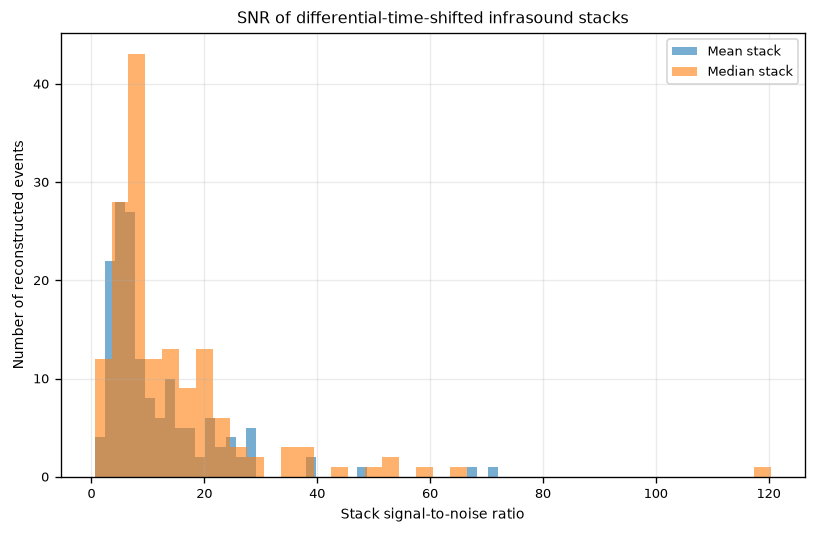

In [17]:
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.hist(
    stack_metrics["mean_stack_snr"].dropna(),
    bins=40,
    alpha=0.6,
    label="Mean stack",
)
ax.hist(
    stack_metrics["median_stack_snr"].dropna(),
    bins=40,
    alpha=0.6,
    label="Median stack",
)
ax.set_xlabel("Stack signal-to-noise ratio")
ax.set_ylabel("Number of reconstructed events")
ax.set_title("SNR of differential-time-shifted infrasound stacks")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    OUTPUT_DIR / "stack_snr_histogram.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 15. HTML gallery with paired unshifted and shifted figures

Each event is displayed as a pair: the original timing on the left and the
corrected/stacked representation on the right.

In [18]:
if WRITE_HTML_GALLERY:
    html_path = OUTPUT_DIR / "reduced_time_event_gallery.html"

    cards = []

    for row in figure_index.itertuples(index=False):
        unshifted_relative = (
            Path("unshifted_png") / row.unshifted_png
        )
        shifted_relative = (
            Path("shifted_png") / row.shifted_png
        )

        cards.append(
            f"""
            <article class="card">
              <h2>Reconstructed event {row.reconstructed_event_number:03d}</h2>
              <p>
                Channels: {html.escape(str(row.channels))}<br>
                Picks: {html.escape(str(row.pick_indices))}<br>
                Corrected span: {row.corrected_pick_span_s:.3f} s<br>
                Legacy match: {row.legacy_event_number}
              </p>
              <div class="pair">
                <a href="{unshifted_relative.as_posix()}">
                  <img src="{unshifted_relative.as_posix()}"
                       alt="Unshifted event">
                </a>
                <a href="{shifted_relative.as_posix()}">
                  <img src="{shifted_relative.as_posix()}"
                       alt="Shifted event">
                </a>
              </div>
            </article>
            """
        )

    document = f"""
    <!doctype html>
    <html lang="en">
    <head>
      <meta charset="utf-8">
      <meta name="viewport"
            content="width=device-width, initial-scale=1">
      <title>Reduced-time Falcon 9 event review</title>
      <style>
        body {{
          font-family: -apple-system, BlinkMacSystemFont,
                       "Segoe UI", sans-serif;
          margin: 1.5rem;
          background: #f4f4f4;
          color: #222;
        }}
        .card {{
          background: white;
          border: 1px solid #ddd;
          border-radius: 8px;
          padding: 0.8rem;
          margin-bottom: 1rem;
        }}
        .pair {{
          display: grid;
          grid-template-columns: repeat(2, minmax(0, 1fr));
          gap: 0.75rem;
        }}
        img {{
          width: 100%;
          height: auto;
          border: 1px solid #eee;
        }}
        h2 {{
          font-size: 1rem;
          margin: 0 0 0.4rem;
        }}
        p {{
          font-size: 0.86rem;
          line-height: 1.4;
        }}
      </style>
    </head>
    <body>
      <h1>Falcon 9 reduced-time event review</h1>
      <p>
        Left: original waveform timing. Right: differentially shifted
        infrasound traces and aligned stacks.
      </p>
      {''.join(cards)}
    </body>
    </html>
    """

    html_path.write_text(document, encoding="utf-8")
    print(f"Wrote HTML gallery: {html_path}")
else:
    print("HTML gallery disabled.")

Wrote HTML gallery: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/event_waveform_review_reduced_time/reduced_time_event_gallery.html


## 16. Outputs and interpretation

Main outputs:

```text
outputs/event_waveform_review_reduced_time/
    unshifted_png/
    shifted_png/
    derived/
        reduced_time_association_window_sweep.csv
        reduced_time_pick_assignments.csv
        reconstructed_reduced_time_events.csv
        reconstructed_reduced_time_events_with_legacy_matches.csv
    event_figure_index.csv
    stack_metrics.csv
    reduced_time_event_gallery.html
```

Recommended review sequence:

1. inspect the association-window sensitivity plot;
2. choose the smallest window that produces stable multi-channel clusters;
3. inspect unassociated picks and duplicate-channel candidates;
4. review paired unshifted/shifted figures;
5. determine whether stacked waveforms improve coherence and reveal weak
   events;
6. update the definitive catalogue only after visual review.